In [ ]:
import pandas as pd
from scipy.stats import zscore
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
from sklearn.metrics import r2_score
import torch.nn.functional as F
import tqdm

**Used links from github to load the data neatly and create dataframes**

In [ ]:
url_train = "https://raw.githubusercontent.com/prakharworkcode-ai/cir-finance/main/train_data.csv"

url_test_ans = "https://raw.githubusercontent.com/prakharworkcode-ai/cir-finance/main/test_data.csv"

url_test = "https://raw.githubusercontent.com/prakharworkcode-ai/cir-finance/main/test_data_3M.csv"

df_train = pd.read_csv(url_train)
df_test_ans = pd.read_csv(url_test_ans)
df_test = pd.read_csv(url_test)


**DATA CLEANING**
1. We format the columns.
2. Convert the Date to DateTime value.
3. Sort the df on basis of date

In [ ]:
def data_cleaning(df):
  df.columns = df.columns.str.strip()
  df['Date'] = pd.to_datetime(df['Date'])
  df = df.sort_values('Date')
  return df

In [ ]:
df_train.head()

,Date,ZC025YR,ZC050YR,ZC075YR,ZC100YR,ZC200YR,ZC500YR,ZC1000YR,ZC2000YR,ZC3000YR
0,2016-05-19,0.005283,0.005640,0.005846,0.006051,0.006146,0.007912,0.014099,0.021224,0.020492
1,2016-05-20,0.005286,0.005642,0.005848,0.006053,0.006176,0.007922,0.014179,0.021353,0.020625
2,2016-05-24,0.005298,0.005651,0.005856,0.006062,0.006228,0.008108,0.014379,0.021534,0.020793
3,2016-05-25,0.005351,0.005603,0.005809,0.006014,0.006281,0.008323,0.014548,0.021596,0.020855
4,2016-05-26,0.005354,0.005605,0.005811,0.006016,0.006115,0.007934,0.013937,0.021326,0.020591


In [ ]:
df_train.columns

Index(['Date', ' ZC025YR', ' ZC050YR', ' ZC075YR', ' ZC100YR', ' ZC200YR',
       ' ZC500YR', ' ZC1000YR', ' ZC2000YR', ' ZC3000YR'],
      dtype='object')

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1976 entries, 0 to 1975
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1976 non-null   object 
 1    ZC025YR   1976 non-null   float64
 2    ZC050YR   1976 non-null   float64
 3    ZC075YR   1976 non-null   float64
 4    ZC100YR   1976 non-null   float64
 5    ZC200YR   1976 non-null   float64
 6    ZC500YR   1976 non-null   float64
 7    ZC1000YR  1976 non-null   float64
 8    ZC2000YR  1976 non-null   float64
 9    ZC3000YR  1976 non-null   float64
dtypes: float64(9), object(1)
memory usage: 154.5+ KB


In [ ]:

df_train = data_cleaning(df_train)
df_test = data_cleaning(df_test)
df_test_ans = data_cleaning(df_test_ans)



**Creating the yield output for training.**

In [ ]:
cols = ['ZC025YR','ZC050YR','ZC075YR','ZC100YR','ZC200YR','ZC500YR','ZC1000YR','ZC2000YR','ZC3000YR']
yield_tensor = torch.tensor(
    df_train[cols].values,
    dtype=torch.float64
)
yield_output_train = yield_tensor[1:, :]

**Plotting the data using Matplotlib**

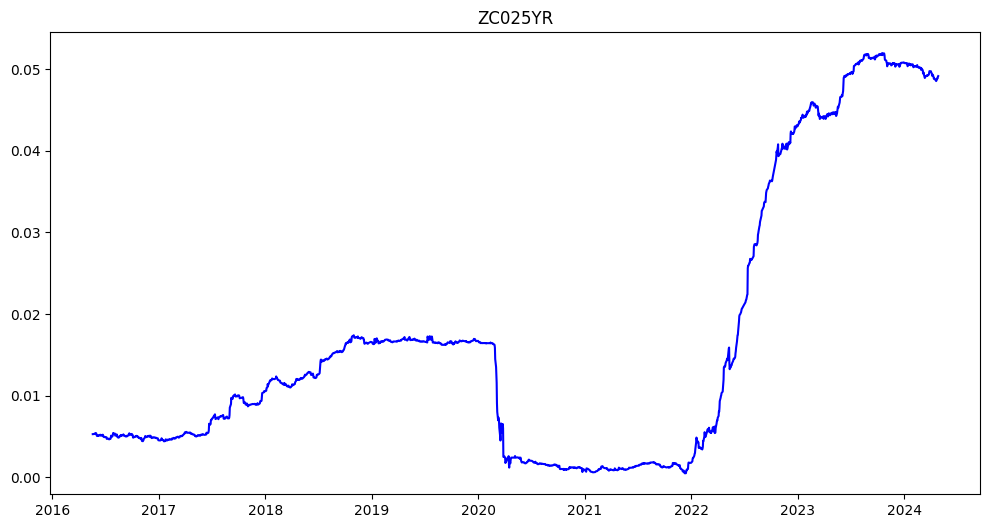

In [ ]:
def plot(df,maturity, predictions  = None):
  try:
    maturity_int_dict = {0.25: "ZC025YR",0.50: "ZC050YR",0.75: "ZC075YR",1: "ZC100YR",2: "ZC200YR",5: "ZC500YR",10: "ZC1000YR",20: "ZC2000YR",30: "ZC3000YR"}

    plt.figure(figsize=(12,6))
    plt.plot(df['Date'], df[maturity_int_dict[maturity]], c='b')
    if predictions is not None:
        plt.plot(df['Date'], torch.cat((torch.tensor([df[maturity_int_dict[maturity]][0]]), torch.tensor(predictions))), c='g')

    plt.title(maturity_int_dict[maturity])
    plt.show()
  except:
    return
plot(df_train, 0.25)
def plot_all(df, yield_pred, maturities):
  for i, maturity in enumerate(maturities):
    plot(df, maturity, yield_pred[:, i].detach().numpy())

In [ ]:
r_t = df_train['ZC025YR'].values
r_t

array([0.0052827, 0.0052855, 0.0052978, ..., 0.0488899, 0.0491045,
       0.0491654])

In [ ]:
r = torch.tensor(r_t, dtype = torch.float64)

r_input_train = r[:-1]
r_output_train = r[1:]
r_input_train, r_output_train
mean = r_input_train.mean()

In [ ]:
loss_fn = nn.L1Loss()

**The formula used to generate the yield curve for the future maturities**
$$\gamma = \sqrt{\kappa^2 + 2\sigma^2}$$
$$A(\tau)
=
\left[
\frac{
2\gamma e^{(\kappa+\gamma)\tau/2}
}{
(\gamma+\kappa)(e^{\gamma\tau}-1)+2\gamma
}
\right]^{\frac{2\kappa\theta}{\sigma^2}}$$

$$B(\tau)
=
\frac{
2(e^{\gamma\tau}-1)
}{
(\gamma+\kappa)(e^{\gamma\tau}-1)+2\gamma
}$$

$$P(t,T)
=
A(\tau)e^{-B(\tau)r_t}$$ where $$\tau = T-t$$

$$y(t,\tau)
=
-\frac{\ln(P(t,T))}{\tau}$$

In [ ]:
#expressions for calculating the yield.

def gamma(kappa, sigma):
  return torch.sqrt(kappa**2 + 2 * sigma**2)

def A(tau, kappa, sigma, theta):
  g = gamma(kappa, sigma)
  N = 2 * g * torch.exp((kappa + g)/2 * tau)
  D = (g + kappa) * (torch.exp(g * tau) - 1) + 2 * g
  power = (2 * kappa * g )/ sigma ** 2
  return torch.pow(N/D, power)

def B(tau, kappa, sigma, theta):
  g = gamma(kappa, sigma)
  N = 2 * (torch.exp(g * tau) - 1)
  D = (g + kappa) * (torch.exp(g * tau) - 1) + 2 * g
  return N/D

def P(r_t, tau, kappa, sigma, theta):
  a = A(tau, kappa, sigma, theta)
  b = B(tau, kappa, sigma, theta)
  p =  a * torch.exp(-b * r_t)
  return p

def y(r_t, tau, kappa, sigma, theta):
  p = P(r_t, tau, kappa, sigma, theta)
  return -torch.log(p)/tau



In [ ]:
def gen_yields(r_pred, model, maturities):

 # This function generates the yields for the future maturities.

  yield_pred = torch.empty(
    (len(r_pred), 0),
    dtype=torch.float64
  )

  for i in maturities:

    yield_ = y(r_pred, i, model.kappa, model.sigma, model.theta).unsqueeze(1)
    yield_pred = torch.cat(
    (yield_pred, yield_),
    dim=1
    )
  return yield_pred

In [ ]:
df_test.head()

,Date,ZC025YR
0,2024-04-29,0.049144
1,2024-04-30,0.049156
2,2024-05-01,0.049100
3,2024-05-02,0.048921
4,2024-05-03,0.048633


In [ ]:
df_test_ans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 495 entries, 0 to 494
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     495 non-null    datetime64[ns]
 1   ZC025YR  495 non-null    float64       
 2   ZC050YR  495 non-null    float64       
 3   ZC075YR  495 non-null    float64       
 4   ZC100YR  495 non-null    float64       
 5   ZC200YR  495 non-null    float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 23.3 KB


In [ ]:

df_test_ans.describe()

,Date,ZC025YR,ZC050YR,ZC075YR,ZC100YR,ZC200YR
count,495,495.000000,495.000000,495.000000,495.000000,495.000000
mean,2025-04-26 16:29:05.454545408,0.030417,0.030043,0.029617,0.029311,0.028745
min,2024-04-29 00:00:00,0.021697,0.022157,0.022400,0.022617,0.023521
25%,2024-10-26 12:00:00,0.023063,0.023745,0.024245,0.024547,0.025433
50%,2025-04-25 00:00:00,0.026580,0.026506,0.026326,0.026292,0.026990
75%,2025-10-27 12:00:00,0.035119,0.034251,0.033204,0.032314,0.030237
max,2026-04-29 00:00:00,0.049156,0.048110,0.047068,0.046093,0.042923
std,NaN,0.008508,0.007889,0.007227,0.006588,0.004682


In [ ]:
r_test_t = df_test['ZC025YR'].values

In [ ]:
r_test = torch.tensor(r_test_t, dtype = torch.float)
r_test_input = r_test[1:]
r_test_output = r_test[:-1]

In [ ]:
cols = ['ZC025YR','ZC050YR','ZC075YR','ZC100YR','ZC200YR']
yield_tensor = torch.tensor(
    df_test_ans[cols].values,
    dtype=torch.float64
)
yield_output_test = yield_tensor[1:, :]
yield_output_test

tensor([[0.0492, 0.0481, 0.0471, 0.0461, 0.0429],
        [0.0491, 0.0481, 0.0470, 0.0460, 0.0424],
        [0.0489, 0.0480, 0.0468, 0.0457, 0.0419],
        ...,
        [0.0229, 0.0237, 0.0246, 0.0254, 0.0281],
        [0.0229, 0.0238, 0.0247, 0.0256, 0.0285],
        [0.0229, 0.0244, 0.0257, 0.0269, 0.0300]], dtype=torch.float64)

In [ ]:
maturities_train = [0.25, 0.5, 0.75, 1, 2, 5, 10, 20, 30]
maturities_test = [0.25, 0.5, 0.75, 1, 2]

In [ ]:
cols = [
    'ZC025YR',
    'ZC050YR',
    'ZC075YR',
    'ZC100YR',
    'ZC200YR'
    ]
yield_tensor = torch.tensor(
    df_test_ans[cols].values,
    dtype=torch.float64
)
yield_output_test = yield_tensor[1:, :]
yield_output_test

tensor([[0.0492, 0.0481, 0.0471, 0.0461, 0.0429],
        [0.0491, 0.0481, 0.0470, 0.0460, 0.0424],
        [0.0489, 0.0480, 0.0468, 0.0457, 0.0419],
        ...,
        [0.0229, 0.0237, 0.0246, 0.0254, 0.0281],
        [0.0229, 0.0238, 0.0247, 0.0256, 0.0285],
        [0.0229, 0.0244, 0.0257, 0.0269, 0.0300]], dtype=torch.float64)

Using euler forward method on the expression
$$dr_t = \kappa(\theta-r_t)\,dt + \sigma\sqrt{r_t}\,dW_t$$

$$r_{t+\Delta t}=r_t+\kappa(\theta-r_t)\Delta t+\sigma\sqrt{r_t}\sqrt{\Delta t}\,\varepsilon_t$$ where $$\varepsilon_t \sim N(0,1)$$
The direct curve fitting approach exhibits a significant parameter unstability as small changes can widely change the results. To get more stable result we introduce mle so that model can learn the drift at a short interval.


During training only deterministic drift was used. The diffusion introduces random noise which makes the model unstable.



The model was trained on conditional expectation.

$$\mathbb{E}[r_{t+\Delta t}\mid r_t]
=
r_t + \kappa(\theta-r_t)\Delta t$$

# **BASE CIR MODEL**

In [ ]:
import torch
import torch.nn as nn


class CIRModel_2(nn.Module):

    def __init__(self):

        super().__init__()

        self.raw_kappa = nn.Parameter(torch.tensor(-3.5, dtype=torch.float64))

        self.raw_theta = nn.Parameter(mean) # assuming the level is the average of all the yields in the curve.

        self.raw_sigma = nn.Parameter(torch.tensor(-1.0, dtype=torch.float64))

    @property
    def kappa(self):
        return F.softplus(self.raw_kappa)

    @property
    def theta(self):
        return F.softplus(self.raw_theta)

    @property
    def sigma(self):
        return F.softplus(self.raw_sigma)

    def forward(self, r_t: torch.Tensor) -> torch.Tensor:

        dt = 1/252
        r_t = torch.clamp(r_t, min=1e-6)
        r_next = (r_t + self.kappa * (self.theta - r_t) * dt)

        return r_next

In [ ]:
model_2 = CIRModel_2()
optimizer = torch.optim.Adam(model_2.parameters(),lr=1e-3)

Economic crisis can lead to violation of feller condition. In environments where volatility determines the rates as compared to level.So any shock can suddenly decrease the interest rate to zero as compared to mean reversion.

In calibrating the model, we used parameter constraints and softplus to ensure parameters stay positive.

In the loss function, we have also introduced feller penalty so that the optimizer also considers.



**MLE expression**

conditional mean
$$
\mu_t = r_t + \kappa(\theta-r_t)\Delta t
$$
conditional variance
$$
v_t = \sigma^2 r_t \Delta t
$$
negative log of L.

L is a product of conditional of r + del(t) | r in parameters of kappa, sigma, theta over all data points.
$$
-\log L
=
\frac{1}{2}
\sum_{t}
\left[
\log(2\pi v_t)
+
\frac{(r_{t+1}-\mu_t)^2}{v_t}
\right]
$$


In [ ]:
def get_loss(r_input,r_input_train, r_output_train, model, yield_output_train, maturities):
  variance = model.sigma ** 2 * r_input_train * (1/252)
  variance = torch.clamp(variance, min = 1e-10)
  mle_loss = 0.5 * (torch.log(2 * torch.pi * variance) + ((r_output_train - r_input) ** 2 / variance)).mean() # maximum likelihood estimation for the interest rate
  feller_penalty = torch.relu(model.sigma**2 - 2 * model.kappa * model.theta) #feller penalty is introduced used pytorch relu activation function.
  mse_loss = 0
  weights = [1, 1, 1, 1, 2, 2, 3, 4, 4]
  yield_pred_train = gen_yields(r_input, model, maturities)
  for i in range(9):
    mse_loss += weights[i] * loss_fn(yield_pred_train[:, i], yield_output_train[:, i])

  return (mle_loss + mse_loss + 10 * feller_penalty)

In [ ]:
epochs = 10000
epoch_count = []
loss_values = []
for epoch in tqdm.tqdm(range(epochs)):
  model_2.train()
  r_pred = model_2(r_input_train)

  loss = get_loss(r_pred,r_input_train, r_output_train, model_2, yield_output_train, maturities_train)
  optimizer.zero_grad()
  loss.backward()
  torch.nn.utils.clip_grad_norm_(
        model_2.parameters(),
        1.0
    )
  optimizer.step()








  5%|▍         | 453/10000 [00:05<01:51, 85.32it/s] 


KeyboardInterrupt: 

As we can see the model can capture yield with maturities within a year pretty well along with the drift very well. But as we go beyond that various other macroeconomic factors also need to be considerd. This can't be done very well with base CIR model.

A Two factor CIR with two independent processes to capture the short term and long term yield rate would help us to extend it well.

As we see the r2 score, the drop becomes significant after a year.

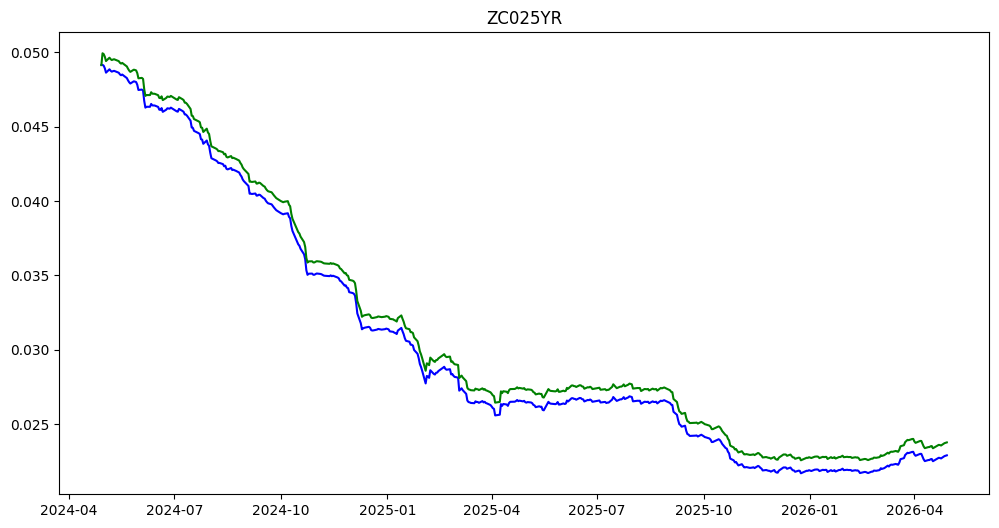

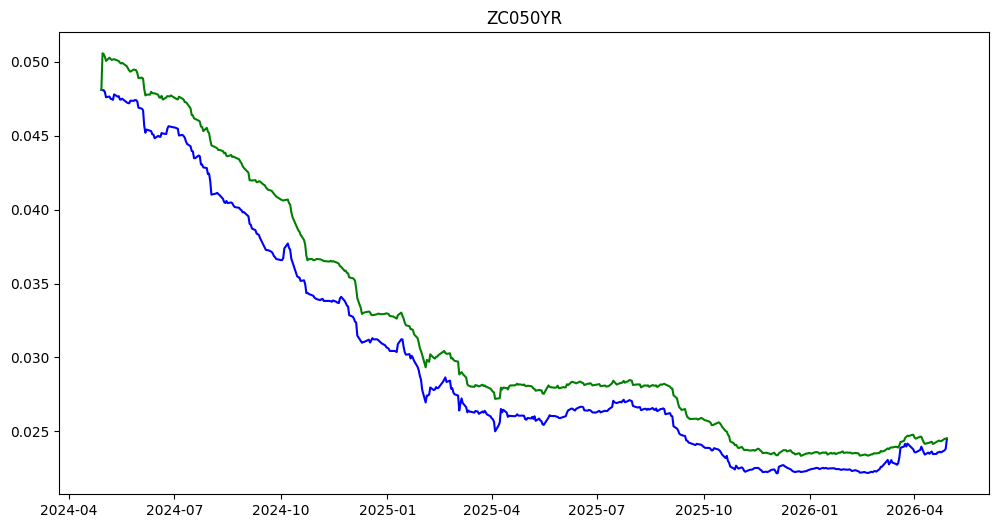

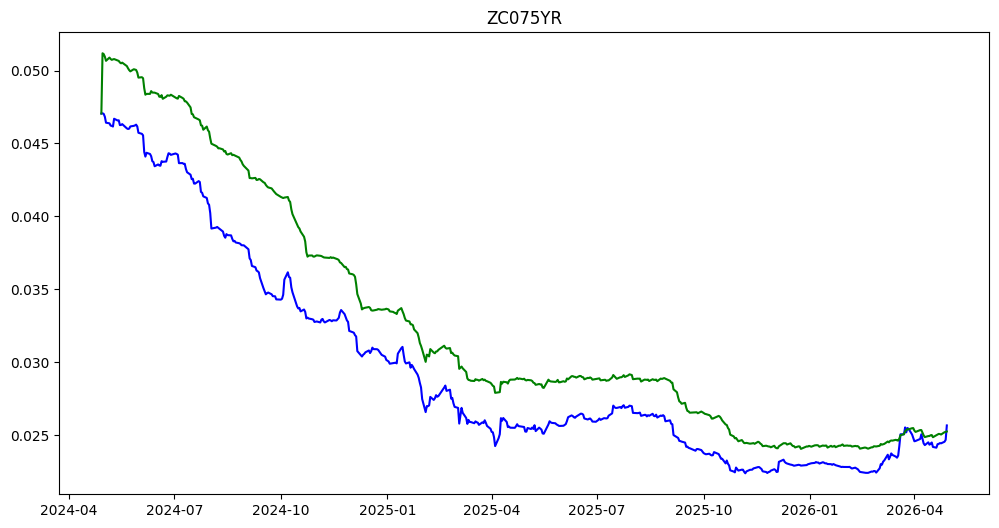

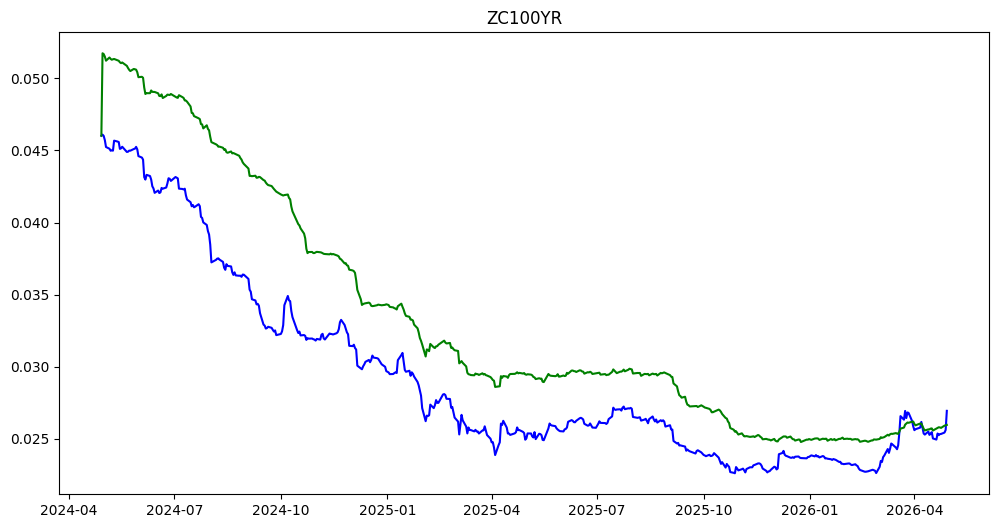

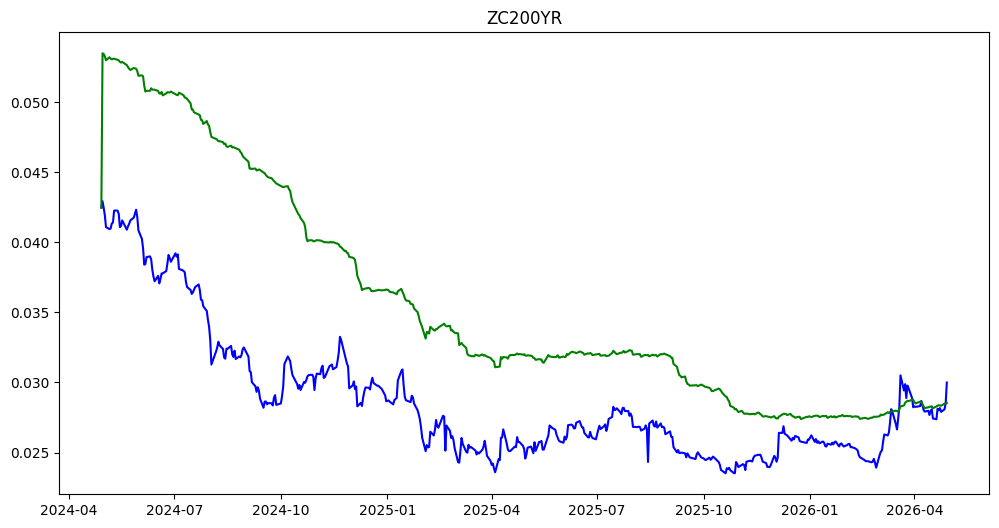

In [ ]:
with torch.no_grad():
  r_pred_test = model_2(r_test_input)
yield_pred_test = gen_yields(r_pred_test,model_2, maturities_test)
plot_all(df_test_ans, yield_pred_test, maturities_test)

In [ ]:

r2 = r2_score(
      yield_output_test.detach().numpy(),
      yield_pred_test.detach().numpy()
  )
print(r2)



0.22301304252036055


The residual mean is negative meaning the model is overpredicting.

Since the mean is so close to zero we can safely say there is no systematic bias so the residuals are approximately centered around zero. The model is systematically overpredicting or underpredicting the value.

In [ ]:
residuals = []
for i in range(5):
  residual_ = (
      yield_output_test[:,i]
      - yield_pred_test[:,i]
  )
  residuals.append(residual_)
  print(residual_.mean())

tensor(-0.0008, dtype=torch.float64, grad_fn=<MeanBackward0>)
tensor(-0.0019, dtype=torch.float64, grad_fn=<MeanBackward0>)
tensor(-0.0031, dtype=torch.float64, grad_fn=<MeanBackward0>)
tensor(-0.0040, dtype=torch.float64, grad_fn=<MeanBackward0>)
tensor(-0.0069, dtype=torch.float64, grad_fn=<MeanBackward0>)


# **CIR++ Model**

CIR++ Model includes a time dependent deterministic factor in the interest rate.
So r(t) = x(t) + phi(t) where phi(t) is time dependent learnable parameters included to capture more information from the yield rates.

phi(t) allows the additional flexibility to the model to fit maturity related effects. The base model struggled to learn information about maturity dependent yields and introducing phi(t) allowed model to learn parameters that vary over maturity durations.

In [ ]:
import torch
import torch.nn as nn


class CIRModel_Improv(nn.Module):

    def __init__(self):

        super().__init__()

        self.raw_kappa = nn.Parameter(torch.tensor(-1.0, dtype=torch.float64))

        self.raw_theta = nn.Parameter(torch.tensor(-4.0, dtype=torch.float64))

        self.raw_sigma = nn.Parameter(torch.tensor(-3.0, dtype=torch.float64))
        self.params = nn.Parameter(torch.randn(3, dtype=torch.float64))
        self.shift = nn.Parameter(torch.zeros(9, dtype = torch.float64))
    @property
    def kappa(self):
        return F.softplus(self.raw_kappa)

    @property
    def theta(self):
        return F.softplus(self.raw_theta)

    @property
    def sigma(self):
        return F.softplus(self.raw_sigma)

    def forward(self, r_t: torch.Tensor) -> torch.Tensor:

        dt = 1/252
        r_t = torch.clamp(r_t, min=1e-6)
        r_next = (r_t + self.kappa * (self.theta - r_t) * dt)

        return r_next

We introduce a time dependent shift in the curve.

In the shift we have 3 components:
1. A constant shift for each maturity duration.
2. A quadratic function with learnable parameters to give flexibility to model.


In [ ]:
def gen_shift(tau, model):
  term_3 = model.params[0] + model.params[1] * tau + model.params[2] * tau * tau
  return term_3


In [ ]:
def gen_yields(r_pred, model, maturities):

 # This function generates the yields for the future maturities.

  yield_pred = torch.empty(
    (len(r_pred), 0),
    dtype=torch.float64
  )


  for i in range(len(maturities)):
    shift = gen_shift(maturities[i], model)
    yield_ = (y(r_pred, maturities[i], model.kappa, model.sigma, model.theta) + shift + model.shift[i]).unsqueeze(1)
    yield_pred = torch.cat(
    (yield_pred, yield_),
    dim=1
    )
  return yield_pred

In [ ]:
model_5 = CIRModel_Improv()


In [ ]:
optimizer = torch.optim.Adam(model_5.parameters(), lr = 1e-3)

In [ ]:
def get_loss(yield_pred, yield_output):
  weights = [1, 1, 2, 2, 3, 3, 4, 5, 5]
  loss = 0
  for i in range(len(weights)):
    loss += weights[i] * loss_fn(yield_pred[:, i], yield_output[:, i]) # adding the l1 loss along with weights for yield across various maturities.
  return loss

# **Training model**

In [ ]:
epochs = 15000
epoch_count = []
loss_values = []
for epoch in range(epochs):
  model_5.train()
  r_pred = model_5(r_input_train)
  yield_pred = gen_yields(r_pred, model_5,maturities_train)
  loss = get_loss(yield_pred, yield_output_train)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  if epoch % 100 == 0:
    epoch_count.append(epoch)
    loss_values.append(loss.item())
    print(loss.item(), epoch)






7643.7599859321 0
6910.308636661016 100
6182.826371846089 200
5455.489961727704 300
4727.623847859929 400
3999.4715243071105 500
3271.143150005691 600


# **Yield Plot for the Train data**

In [ ]:
with torch.no_grad():
  r_pred = model_5(r_input_train)
yield_pred = gen_yields(r_pred, model_5, maturities_test)
plot_all(df_train, yield_pred, maturities_test)

# **Yield Plots for Test Data**

In [ ]:
with torch.no_grad():
  r_pred_test = model_5(r_test_input)
yield_pred_test = gen_yields(r_pred_test, model_5, maturities_test)
plot_all(df_test_ans, yield_pred_test, maturities_test)

CIR model with deterministic shift increases the score for the model to range of 0.85 to 0.90 as compared to the 0.7 using the base CIR model. The base CIR model was able to capture the general level of the yield curve but struggled to generate the yield dependent curves for longer maturities.

Since this improvement was observed on unseen data , this is the proof the deterministic shift captures the maturity dependent structure of the curve. However additional parameters increase the risk of overfitting the model.

# **R_2 Score**

In [ ]:
r2 = r2 = r2_score(
    yield_output_test.detach().numpy(),
    yield_pred_test.detach().numpy()

    )
r2

Mean reversion helps us to determine how quickly the yield recovers after a random shock due to stochastic parametes. A small k means long lasting shocks while a large k means sudden impulses.

In the calibrated model k is relatively modest.

In [ ]:
model_5.kappa

#  **ANALYSIS**
****
**LIMITATIONS**

The base CIR Model performs well for shorter maturities capturing the curves with appreciable accuracy. But for longer maturities, it is not able to predict accurately.

In longer terms, there are various macroeconomic factors that affect the yield of the bond. A single state variable fails to capture that.

Also the optimiser heavily focuses on short term maturities as these help in reducing the loss function considerably. These leads to model never actually focusing on the longer duration yields.

Introducing more parameters also risk the model overfitting the training data. So we can't increase the parameters to learn the curve indefinitely.

In case of risks, we face the usual risks of overpricing and underpricing the asset. The model being basic risks ignoring factors underlying the data.

****

**IMPLICATIONS OF MATHEMATICAL ASSUMPTIONS**

The deterministic functions phi(t) only helps us in learning the maturity dependent trend. The parameters have little to no explanation in economic terms affecting the interpretability of model and it's parameters.


The CIR model assumes interest rates evolving through continuous diffusion process so they fail to capture sudden jerks like financial crisis and geopolitical crisis.

The single state variable underestimates long term maturities and model fails to learn beyond a certain threshold.
****

# **Saving the model**

In [ ]:
from pathlib import Path

MODEL_PATH = Path("content/models")
MODEL_PATH.mkdir(parents = True, exist_ok = True)

MODEL_NAME = "MODEL_CIR.pth"
MODEL_SAVE_PATH = MODEL_PATH/MODEL_NAME
torch.save(obj = model_5.state_dict(), f = MODEL_SAVE_PATH)
print(MODEL_SAVE_PATH.exists(), MODEL_SAVE_PATH)

In [ ]:
torch.load(f = MODEL_PATH/MODEL_NAME)

In [ ]:
loaded_model = CIRModel_Improv()

loaded_model.load_state_dict(torch.load(f = MODEL_SAVE_PATH))

In [ ]:
with torch.no_grad():
  r_pred_test_saved = loaded_model(r_test_input)
yield_pred_test_saved = gen_yields(r_pred_test_saved, model_5, maturities_test)
plot_all(df_test_ans, yield_pred_test_saved, maturities_test)

In [ ]:
r2 = r2 = r2_score(
    yield_output_test.detach().numpy(),
    yield_pred_test_saved.detach().numpy()

    )
r2